# Сверхподробный EDA аугментированного датасета
## Notebook 03: Deep Exploratory Data Analysis

> **Цель ноутбука**: дать исчерпывающее понимание того,
> что находится в датасете, откуда пришли данные, как работала разметка,
> и где остаются риски для обучения модели.

---

### Содержание
1. [Что такое каждый класс?](#section-classes)
2. [Как работала regex-разметка threat/harassment?](#section-regex)
3. [Полная сводка по размерам и источникам](#section-overview)
4. [Анализ длин текстов](#section-lengths)
5. [Сигнальные признаки](#section-signals)
6. [Частотный анализ слов](#section-words)
7. [Сравнение доменов (Авито vs внешние источники)](#section-domain)
8. [Риски и ограничения датасета](#section-risks)
9. [Вывод: что это значит для модели](#section-conclusion)


## 0. Импорты и загрузка

In [1]:
import sys, os, re
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"

from src.eda_plots      import CLASS_ORDER, CLASS_RU, PALETTE
from src.deep_eda_plots import (
    plot_overview, plot_text_lengths, plot_signal_features,
    plot_top_words, plot_regex_analysis, plot_domain_comparison,
    plot_risks, DIRECT_THREAT_RE, TRIGGER_WORDS, SOURCE_RU,
)

# Загружаем все три сплита и объединяем для EDA
TRAIN_PATH = "data/augmented/train.csv"
VAL_PATH   = "data/augmented/val.csv"
TEST_PATH  = "data/augmented/test.csv"

train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)
full  = pd.concat([train, val, test], ignore_index=True)

full["text_len"]   = full["text"].str.len()
full["word_count"] = full["text"].str.split().str.len()

print(f"Загружено: {len(full):,} строк")
print(f"Сплиты: train={len(train):,} / val={len(val):,} / test={len(test):,}")
print(f"Колонки: {full.columns.tolist()}")


Загружено: 388,511 строк
Сплиты: train=316,213 / val=36,149 / test=36,149
Колонки: ['text', 'label', 'source', 'synthetic', 'avito_original', 'text_len', 'word_count']


---
<a id="section-classes"></a>
## 1. Что такое каждый класс?

### Классификация по Авито-контексту

В отличие от общих датасетов токсичности, задача специфична для **мессенджера торговой площадки**.
Пользователи — покупатели и продавцы. Сообщения короткие, деловые. На этом фоне 5 классов:

---

### `normal` — Обычное сообщение
Стандартная деловая коммуникация: вопросы о товаре, договорённости о встрече, торг.
- *«Здравствуйте, когда можно забрать?»*
- *«Скину фото завтра»*
- *«Торг уместен?»*

---

### `external` — Уход с платформы
Попытка перевести переписку **за пределы Авито** (WhatsApp, Telegram, телефон).
Нарушает правила площадки и лишает Авито возможности модерировать переписку.
- *«Напишите на ватсап»*
- *«+79991234567»*
- *«Отправлю фото в телеграм»*
- Также сюда попадают рекрутинговые сообщения с контактами

**Источники**: только реальные Авито-сообщения (4 327) + синтетические (3 676)

---

### `spam` — Спам/Реклама
Нежелательный коммерческий контент, не связанный с предметом объявления.
Рекламные рассылки, сетевой маркетинг, предложения о работе.
- *«Приглашаем подписаться на наш ТЕЛЕГРАМ — white »*
- *«Компания "МеталлПроект" изготавливаем теплицы...»*

**Источники**: 220 реальных + 1 881 синтетический

---

### `harassment` — Харассмент/Оскорбление
Прямые оскорбления, унижения, нецензурная брань в адрес собеседника.
НЕ обязательно угрозы — достаточно оскорбительного намерения.
- *«Ничего страшного. Это авито тварь»*
- *«это пиздец»*

**Источники**: 87 реальных Авито + 204 синтетических + **14 915 из AlexSham (ok.ru)** + **6 060 из s-nlp/ru_paradetox**

---

### `threat` — Угроза
Явная угроза физического вреда или расправы, направленная на конкретного человека.
Более узкий класс чем harassment — нужна выраженная угроза действием.
- *«Ну тебе пизда»*
- *«Найду тебя и сломаю ноги, сука»*
- *«сдохни падаль!»*

**Источники**: 4 реальных Авито + 77 синтетических + **195 из AlexSham (ok.ru)**


In [2]:
print("=== РАЗМЕРЫ КЛАССОВ В ПОЛНОМ ДАТАСЕТЕ ===")
vc = full["label"].value_counts()
for cls in CLASS_ORDER:
    pct = vc.get(cls, 0) / len(full) * 100
    print(f"  {CLASS_RU[cls]:<20}: {vc.get(cls,0):>8,}  ({pct:.2f}%)")


=== РАЗМЕРЫ КЛАССОВ В ПОЛНОМ ДАТАСЕТЕ ===
  Обычное             :  356,865  (91.85%)
  Внешний контакт     :    8,003  (2.06%)
  Спам                :    2,101  (0.54%)
  Харассмент          :   21,266  (5.47%)
  Угроза              :      276  (0.07%)


In [3]:
print("=== ПРИМЕРЫ ПО КЛАССАМ (только Авито-реальные) ===")
for cls in CLASS_ORDER:
    subset = full[(full["label"]==cls) & (full["source"]=="real")]["text"].dropna()
    n = len(subset)
    print(f"\n{'─'*70}")
    print(f"{CLASS_RU[cls].upper()} | Реальных: {n:,}")
    print(f"{'─'*70}")
    for t in subset.sample(min(4, n), random_state=42):
        print(f"  > {str(t)[:110]}")


=== ПРИМЕРЫ ПО КЛАССАМ (только Авито-реальные) ===

──────────────────────────────────────────────────────────────────────
ОБЫЧНОЕ | Реальных: 356,865
──────────────────────────────────────────────────────────────────────
  > Уже не актуально, я вам еще 3 дня назад писала
  > Нужно поменять два смесителя в ванной и раковине? Возьметесь? Жк ростов
  > Добрый день!
Думаю над тем, чтобы заменить плитку на входной группе на резиновое покрытие. Смущает то, что на 
  > И толщина 52см

──────────────────────────────────────────────────────────────────────
ВНЕШНИЙ КОНТАКТ | Реальных: 4,327
──────────────────────────────────────────────────────────────────────
  > напишите на ватсап фото пришлем
  > Добрый день!
Оставьте, пожалуйста, свой контактный номер, с вами свяжется наш сотрудник и все более подробно р
  > ‎Просмотреть товар в WhatsApp: могилы
‎Цена: 2 500,00 ₽
‎Описание: \uD83D\uDE96 Лицензия на такси за 7 дней — 
  > Чсвободевского 14, пишите если что в ватсап можете или здесь как удобн

---
<a id="section-regex"></a>
## 2. Как работала regex-разметка threat/harassment?

### Проблема

Датасет **AlexSham/Toxic_Russian_Comments** содержит только бинарную метку:
- `0` — нейтральный комментарий
- `1` — токсичный комментарий ← нам нужно разбить это на `threat` и `harassment`

### Решение: regex по словам-триггерам прямых угроз

Мы применили регулярное выражение, которое ловит **прямые угрозы конкретному человеку**.
Ключевой критерий: угроза должна быть **адресной** — «ты», «тебя», «сдохни» (императив).

```python
DIRECT_THREAT_RE = re.compile(
    r"убью|убить тебя|пристрелю|застрелю|зарежу|"
    r"сдохни|сдохните|подохни|умри|"
    r"тебе пизда|тебе конец|найду тебя|"
    r"займусь тобой|грохну|замочу|прибью|...",
    re.IGNORECASE,
)
```

**Логика**:
- `text.str.contains(DIRECT_THREAT_RE)` → `True` → метка `threat`
- иначе → метка `harassment`

### Известные ошибки (False Positives в threat)

| Тип | Пример | Проблема |
|---|---|---|
| Общее высказывание | «таких надо убивать» | Не прямая угроза, но содержит «убивать» |
| Политический контекст | «сдохни путокрыса» | Реально угроза, но адресат не собеседник |
| Косвенная угроза | «я тебя запомнил» | Не поймает regex |

Оценка точности эвристики: **≈80-85%** на явных случаях.
Для обучения модели это приемлемо — она увидит паттерны и уточнит границы на реальных val/test примерах.


In [4]:
# Список слов-триггеров
print("=== СЛОВА-ТРИГГЕРЫ для класса threat ===")
for i, tw in enumerate(TRIGGER_WORDS, 1):
    print(f"  {i:2}. [{tw}]")


=== СЛОВА-ТРИГГЕРЫ для класса threat ===
   1. [убью]
   2. [убить тебя]
   3. [пристрелю]
   4. [застрелю]
   5. [зарежу]
   6. [сдохни]
   7. [сдохните]
   8. [подохни]
   9. [умри]
  10. [тебе пизда]
  11. [пизда тебе]
  12. [тебе конец]
  13. [найду тебя]
  14. [найду вас]
  15. [приду за тобой]
  16. [займусь тобой]
  17. [грохну]
  18. [замочу]
  19. [прибью]
  20. [прикончу]


In [5]:
# Статистика срабатывания
alexsham = full[full["source"] == "alexsham"].copy()
print(f"AlexSham-строк в датасете: {len(alexsham):,}")
print(f"Из них threat: {(alexsham['label']=='threat').sum():,}  ({(alexsham['label']=='threat').mean()*100:.1f}%)")
print(f"Из них harassment: {(alexsham['label']=='harassment').sum():,}  ({(alexsham['label']=='harassment').mean()*100:.1f}%)")
print()
print("Частота срабатывания каждого триггера:")
for tw in TRIGGER_WORDS:
    pat = re.compile(re.escape(tw), re.IGNORECASE)
    cnt = alexsham["text"].str.contains(pat, regex=True, na=False).sum()
    if cnt > 0:
        print(f"  [{tw}]: {cnt:,} срабатываний")


AlexSham-строк в датасете: 15,110
Из них threat: 195  (1.3%)
Из них harassment: 14,915  (98.7%)

Частота срабатывания каждого триггера:
  [убью]: 25 срабатываний
  [убить тебя]: 3 срабатываний


  [пристрелю]: 4 срабатываний
  [застрелю]: 4 срабатываний
  [зарежу]: 1 срабатываний
  [сдохни]: 142 срабатываний
  [сдохните]: 22 срабатываний
  [подохни]: 7 срабатываний
  [умри]: 5 срабатываний


  [тебе пизда]: 2 срабатываний
  [пизда тебе]: 4 срабатываний
  [найду тебя]: 3 срабатываний
  [грохну]: 10 срабатываний
  [прибью]: 1 срабатываний


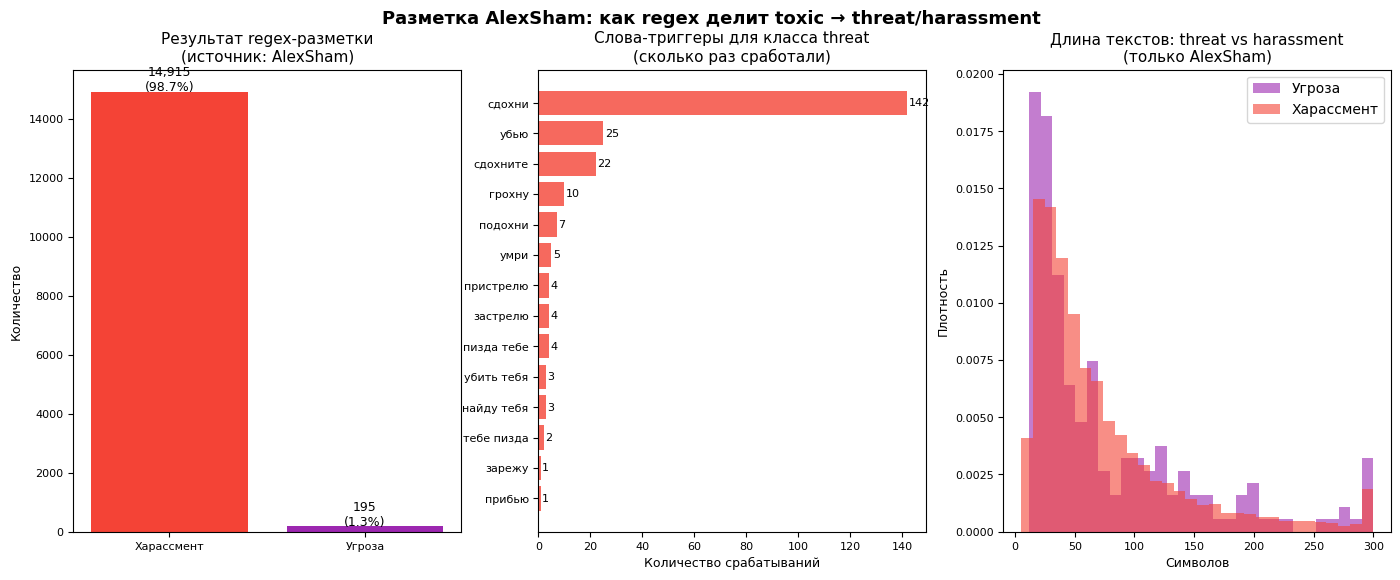

In [6]:
fig = plot_regex_analysis(full, save_path="eda_deep_regex.png")
plt.show()


In [7]:
print("=== СЛУЧАЙНЫЕ ПРИМЕРЫ threat (AlexSham) с указанием триггера ===")
threats_alexsham = full[(full["source"]=="alexsham") & (full["label"]=="threat")]["text"].dropna()
for t in threats_alexsham.sample(min(12, len(threats_alexsham)), random_state=42):
    m = DIRECT_THREAT_RE.search(str(t))
    trigger = f"[{m.group(0)}]" if m else "[???]"
    print(f"  ТРИГГЕР={trigger}")
    print(f"  Текст: {str(t)[:120]}")
    print()


=== СЛУЧАЙНЫЕ ПРИМЕРЫ threat (AlexSham) с указанием триггера ===
  ТРИГГЕР=[сдохни]
  Текст: да тебя не обгадишь, сдохни чмо.

  ТРИГГЕР=[пизда тебе]
  Текст: в таком случае можно что угодно делать все равно пизда тебе

  ТРИГГЕР=[сдохните]
  Текст: американские пидарасы,знайте,если вы все сдохните,буду только рад.(h)

  ТРИГГЕР=[застрелю]
  Текст: я вас шариков застрелю...у самих револьверы найдутся!!!

  ТРИГГЕР=[найду тебя]
  Текст: константин если ты не хуя не знаешь судьбу других то нехуй пиздеть я вырос немецкой деревне могу лучше тебя разговариват

  ТРИГГЕР=[сдохни]
  Текст: пошёл на.….сдохни тварь!!!

  ТРИГГЕР=[сдохни]
  Текст: устали? так сдохни те.

  ТРИГГЕР=[сдохни]
  Текст: ты мразь конченная, сдохни

  ТРИГГЕР=[сдохни]
  Текст: служи дурачек лох з начек толучи и твоя родина давно уже собственность частная сдохни где ниубдь на ка вказе за интересы

  ТРИГГЕР=[убью]
  Текст: я убью его !!!!

  ТРИГГЕР=[сдохни]
  Текст: и сдохни девочкой

  ТРИГГЕР=[сдохните]
  Текст: да с

In [8]:
print("=== СЛУЧАЙНЫЕ ПРИМЕРЫ harassment (AlexSham) — без триггера прямой угрозы ===")
hars_alexsham = full[(full["source"]=="alexsham") & (full["label"]=="harassment")]["text"].dropna()
for t in hars_alexsham.sample(min(12, len(hars_alexsham)), random_state=99):
    print(f"  {str(t)[:120]}")
print()
print("=== ПРИМЕРЫ harassment (paradetox) ===")
hars_para = full[(full["source"]=="paradetox") & (full["label"]=="harassment")]["text"].dropna()
for t in hars_para.sample(min(8, len(hars_para)), random_state=5):
    print(f"  {str(t)[:120]}")


=== СЛУЧАЙНЫЕ ПРИМЕРЫ harassment (AlexSham) — без триггера прямой угрозы ===
  эвген , а отсосать....
  ну и дура твоя жоппа и ты вместе фотографом.
  погибли люди, неужели ты в таком случае не та же самая тварь!!!???
  а в пиндосии просто прибили бы любого
  отрезать и вырезать без наркоза этим тварям
  они как крысы все за бугром будут. педросы самые первые будут трампу жопу лизать ради прибежище за океоном
  какой же ты долбоёб!!! цб не подчиняется рф!!!
  то ли майданутые то ли психанутые ...потом будут нытть что их обманули ...это не свержение путина ..а развал россии вот 
  да одни пидорасы
  менты-козлы! прийдет время, вас также пиздить народ будет!
  не судить, не стрелять. отрубать по локоть руки, отрезать под корень хозяйство и отпускать. живи каскада.
  кто их будет слушать,пусть свалят из европы уроды,потом могут просить,а пока пиндосы ваша задача сосать причмокивая.....

=== ПРИМЕРЫ harassment (paradetox) ===
  Ох уж этот мерзотный кусочек белого фона справа на аватаре
  б

---
<a id="section-overview"></a>
## 3. Полная сводка: размеры и источники


In [9]:
print("=== ПОЛНАЯ МАТРИЦА: класс × источник ===")
ct = full.groupby(["label","source"]).size().unstack(fill_value=0).reindex(CLASS_ORDER)
ct.index = [CLASS_RU[c] for c in CLASS_ORDER]
ct.columns = [SOURCE_RU.get(s, s) for s in ct.columns]
display(ct)

print()
print("=== В ПРОЦЕНТАХ ОТ КЛАССА ===")
ct_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
display(ct_pct.style.background_gradient(cmap="RdYlGn_r", axis=1))


=== ПОЛНАЯ МАТРИЦА: класс × источник ===


,AlexSham (ok.ru),s-nlp/ru_paradetox,Авито (реальные),Синтетические
Обычное,0,0,356865,0
Внешний контакт,0,0,4327,3676
Спам,0,0,220,1881
Харассмент,14915,6060,87,204
Угроза,195,0,4,77



=== В ПРОЦЕНТАХ ОТ КЛАССА ===


,AlexSham (ok.ru),s-nlp/ru_paradetox,Авито (реальные),Синтетические
Обычное,0.000000,0.000000,100.000000,0.000000
Внешний контакт,0.000000,0.000000,54.100000,45.900000
Спам,0.000000,0.000000,10.500000,89.500000
Харассмент,70.100000,28.500000,0.400000,1.000000
Угроза,70.700000,0.000000,1.400000,27.900000


In [10]:
print("=== TRAIN / VAL / TEST ===")
for name, df in [("TRAIN", train), ("VAL", val), ("TEST", test)]:
    print(f"\n{name} ({len(df):,} строк):")
    vc = df["label"].value_counts().reindex(CLASS_ORDER).fillna(0)
    for cls in CLASS_ORDER:
        cnt = int(vc.get(cls, 0))
        pct = cnt / len(df) * 100
        print(f"  {CLASS_RU[cls]:<22}: {cnt:>8,}  ({pct:.2f}%)")


=== TRAIN / VAL / TEST ===

TRAIN (316,213 строк):
  Обычное               :  285,493  (90.29%)
  Внешний контакт       :    7,139  (2.26%)
  Спам                  :    2,057  (0.65%)
  Харассмент            :   21,250  (6.72%)
  Угроза                :      274  (0.09%)

VAL (36,149 строк):
  Обычное               :   35,686  (98.72%)
  Внешний контакт       :      432  (1.20%)
  Спам                  :       22  (0.06%)
  Харассмент            :        8  (0.02%)
  Угроза                :        1  (0.00%)

TEST (36,149 строк):
  Обычное               :   35,686  (98.72%)
  Внешний контакт       :      432  (1.20%)
  Спам                  :       22  (0.06%)
  Харассмент            :        8  (0.02%)
  Угроза                :        1  (0.00%)


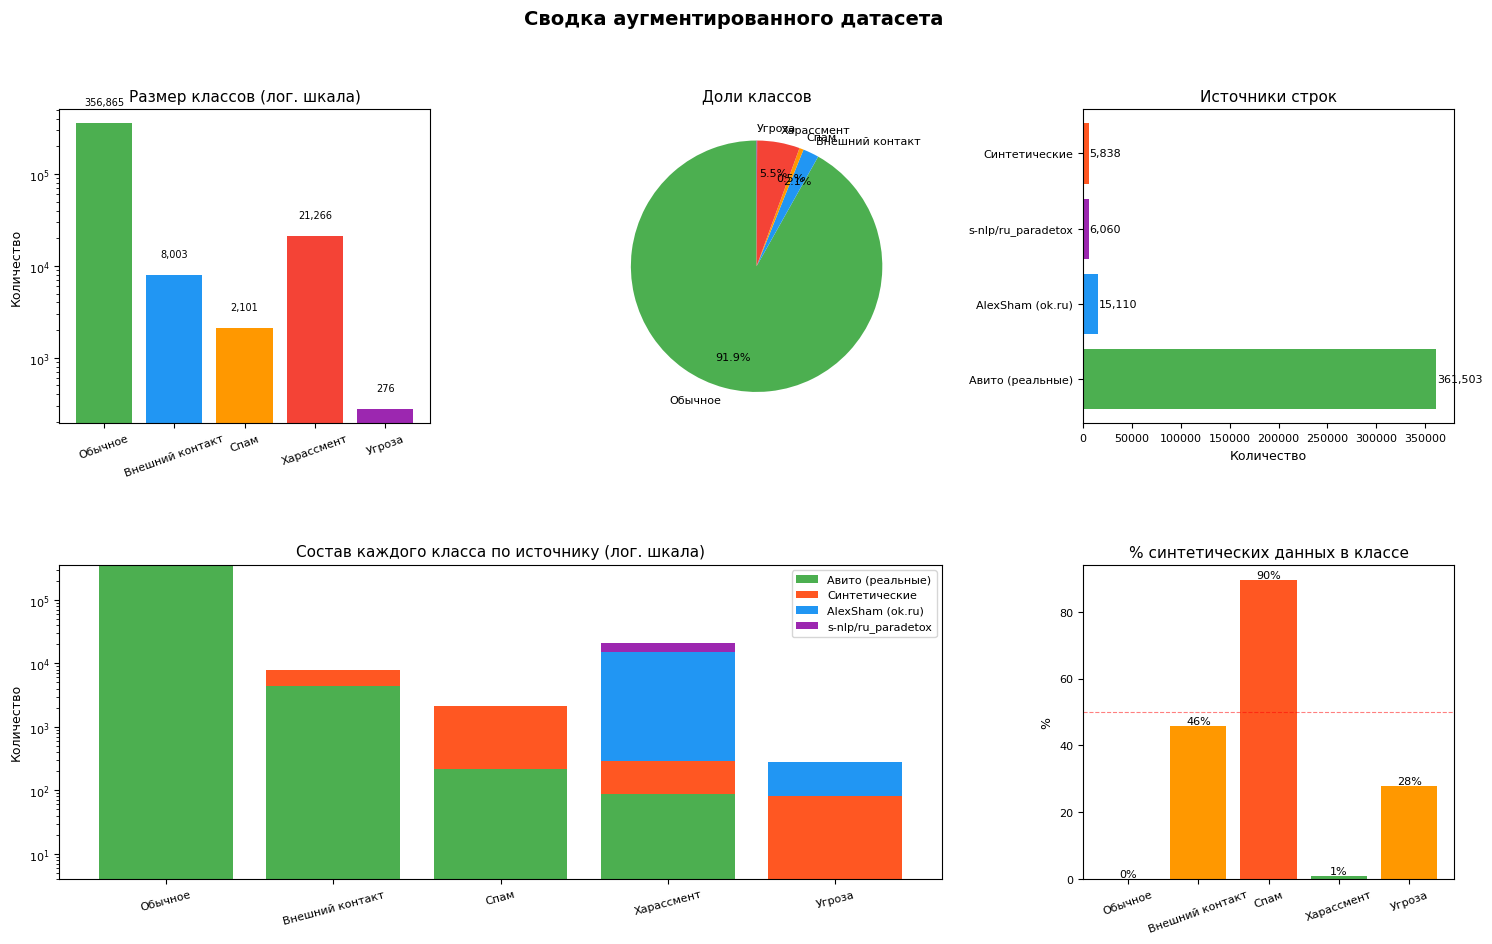

In [11]:
fig = plot_overview(full, save_path="eda_deep_overview.png")
plt.show()


---
<a id="section-lengths"></a>
## 4. Анализ длин текстов

Длина сообщения — **важный сигнал** для классификатора:
- `spam` и `external` заметно длиннее (много контактных данных, рекламный текст)
- `normal` преимущественно короткие (деловые реплики)
- `harassment` и `threat` — короткие, но с выбросами (длинные ругательства)


In [12]:
print("=== ПОДРОБНАЯ СТАТИСТИКА ДЛИН ПО КЛАССАМ ===")
stats = full.groupby("label")[["text_len","word_count"]].describe().round(1)
# Переименуем индекс
stats.index = [CLASS_RU[c] for c in CLASS_ORDER]
display(stats)


=== ПОДРОБНАЯ СТАТИСТИКА ДЛИН ПО КЛАССАМ ===


text_len                                                 \
                    count   mean    std   min   25%   50%    75%     max   
Обычное            8003.0  151.6  187.2   2.0  32.0  78.0  213.0  2328.0   
Внешний контакт   21266.0   70.2   57.3   3.0  33.0  54.0   87.0   546.0   
Спам             356865.0   55.0   80.2   2.0  21.0  35.0   59.0  1460.0   
Харассмент         2101.0  142.7  140.7   8.0  66.0  97.0  149.0  1050.0   
Угроза              276.0   72.7   70.4  11.0  27.0  47.5   95.0   388.0   

                word_count                                            
                     count  mean   std  min   25%   50%   75%    max  
Обычное             8003.0  21.8  26.3  1.0   5.0  12.0  31.0  332.0  
Внешний контакт    21266.0  11.4   9.4  1.0   6.0   9.0  14.0   81.0  
Спам              356865.0   8.6  12.4  1.0   3.0   5.0   9.0  217.0  
Харассмент          2101.0  24.6  24.3  2.0  12.0  17.0  26.0  194.0  
Угроза               276.0  12.0  12.6  1.0   4.0   7.0  15.0   73.0

In [13]:
print("=== БИННИНГ ДЛИН (% строк класса) ===")
full_temp = full.copy()
full_temp["len_bin"] = pd.cut(full_temp["text_len"],
                               bins=[0, 25, 75, 200, 10000],
                               labels=["<25 симв.", "25–75 симв.", "75–200 симв.", ">200 симв."])
lb = full_temp.groupby(["label","len_bin"], observed=False).size().unstack(fill_value=0)
lb_pct = lb.div(lb.sum(axis=1), axis=0).mul(100).round(1).reindex(CLASS_ORDER)
lb_pct.index = [CLASS_RU[c] for c in CLASS_ORDER]
display(lb_pct.style.background_gradient(cmap="Blues", axis=1))


=== БИННИНГ ДЛИН (% строк класса) ===


len_bin,<25 симв.,25–75 симв.,75–200 симв.,>200 симв.
Обычное,34.300000,48.600000,13.900000,3.100000
Внешний контакт,19.700000,29.200000,24.700000,26.400000
Спам,1.600000,33.100000,48.300000,17.000000
Харассмент,14.800000,53.800000,27.200000,4.200000
Угроза,22.800000,48.200000,23.200000,5.800000


/Users/bulletqueen/Desktop/Итоговый проект/src/deep_eda_plots.py:220: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outlier_pct = df.groupby("label").apply(


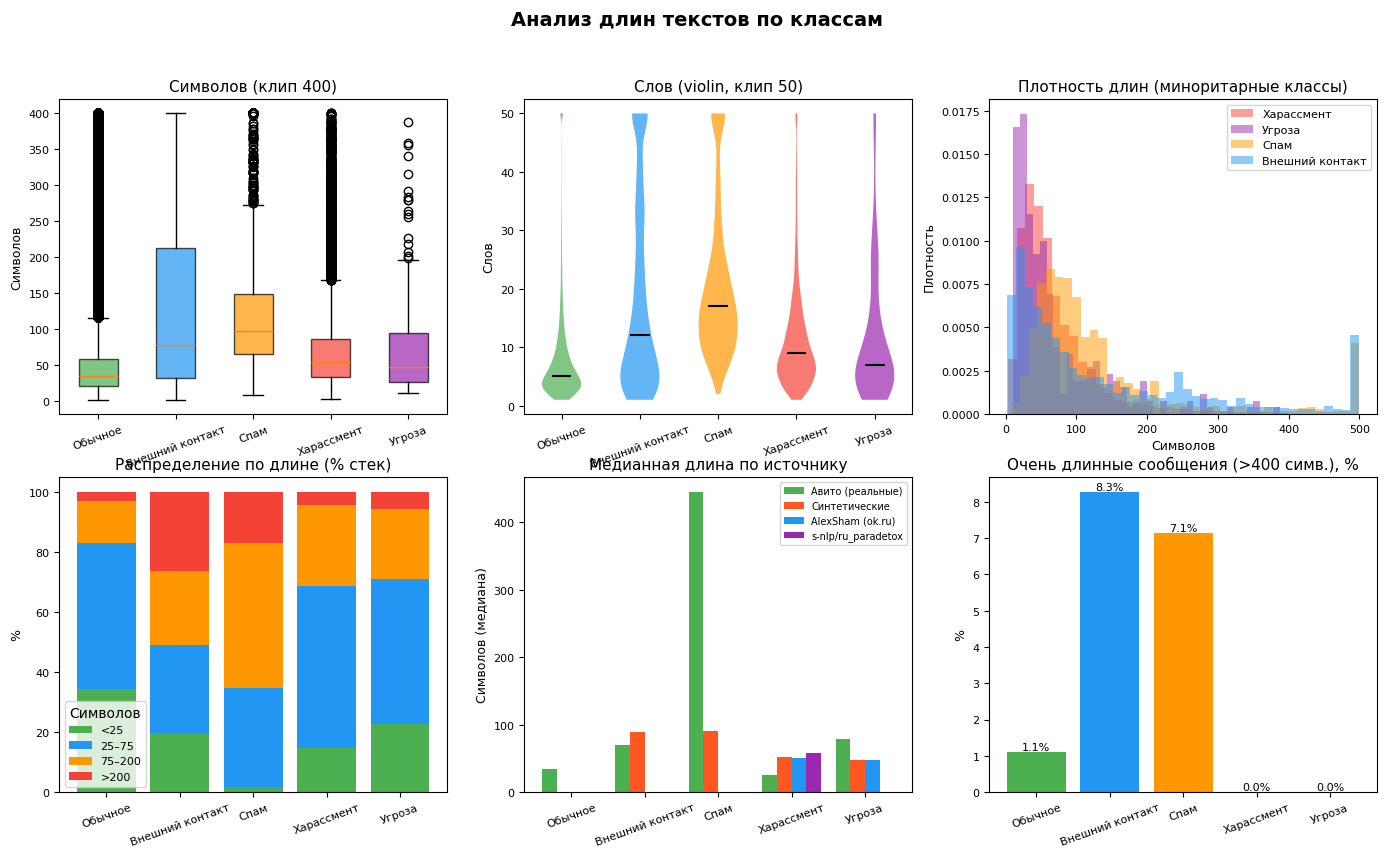

In [14]:
fig = plot_text_lengths(full, save_path="eda_deep_lengths.png")
plt.show()


---
<a id="section-signals"></a>
## 5. Сигнальные признаки (ключевые маркеры классов)

Простые rule-based признаки, которые сильно коррелируют с отдельными классами.
Полезно понимать, чтобы:
1. Добавить их как дополнительные features модели
2. Знать, какие ошибки ожидать


In [15]:
full_feat = full.copy()
full_feat["Номер телефона"]      = full_feat["text"].str.contains(
    r"\+?7[\s\-\(]?\d{3}|\b\d{10,11}\b", na=False)
full_feat["WhatsApp/Telegram"]   = full_feat["text"].str.contains(
    r"ватсап|вотсап|whatsapp|telegram|телеграм|t\.me/", na=False, flags=re.IGNORECASE)
full_feat["URL-ссылка"]          = full_feat["text"].str.contains(
    r"https?://", na=False)
full_feat["Нецензурная лексика"] = full_feat["text"].str.contains(
    r"пизд|ёб[её]|хуй|блядь|сук[аи]|ёбан|ебан|мразь|тварь", na=False, flags=re.IGNORECASE)
full_feat["Эмодзи"]              = full_feat["text"].str.contains(
    r"[\U0001F300-\U0001FFFF]", na=False)
full_feat["Много КАПСЛОКА (>40%)"] = full_feat["text"].apply(
    lambda t: sum(1 for c in str(t) if c.isupper()) / max(len(str(t)), 1) > 0.4)

feat_cols = ["Номер телефона","WhatsApp/Telegram","URL-ссылка",
             "Нецензурная лексика","Эмодзи","Много КАПСЛОКА (>40%)"]

print("=== % СТРОК С ПРИЗНАКОМ (по классам) ===")
feat_tbl = full_feat.groupby("label")[feat_cols].mean().mul(100).round(1).reindex(CLASS_ORDER)
feat_tbl.index = [CLASS_RU[c] for c in CLASS_ORDER]
display(feat_tbl.style.background_gradient(cmap="YlOrRd", axis=0))


=== % СТРОК С ПРИЗНАКОМ (по классам) ===


,Номер телефона,WhatsApp/Telegram,URL-ссылка,Нецензурная лексика,Эмодзи,Много КАПСЛОКА (>40%)
Обычное,3.100000,0.300000,0.300000,0.000000,0.000000,0.300000
Внешний контакт,35.400000,37.200000,0.600000,0.000000,2.600000,0.100000
Спам,7.600000,7.100000,4.000000,0.000000,29.100000,2.200000
Харассмент,0.100000,0.000000,0.100000,28.500000,4.400000,2.400000
Угроза,0.700000,0.700000,0.000000,45.300000,5.100000,0.000000


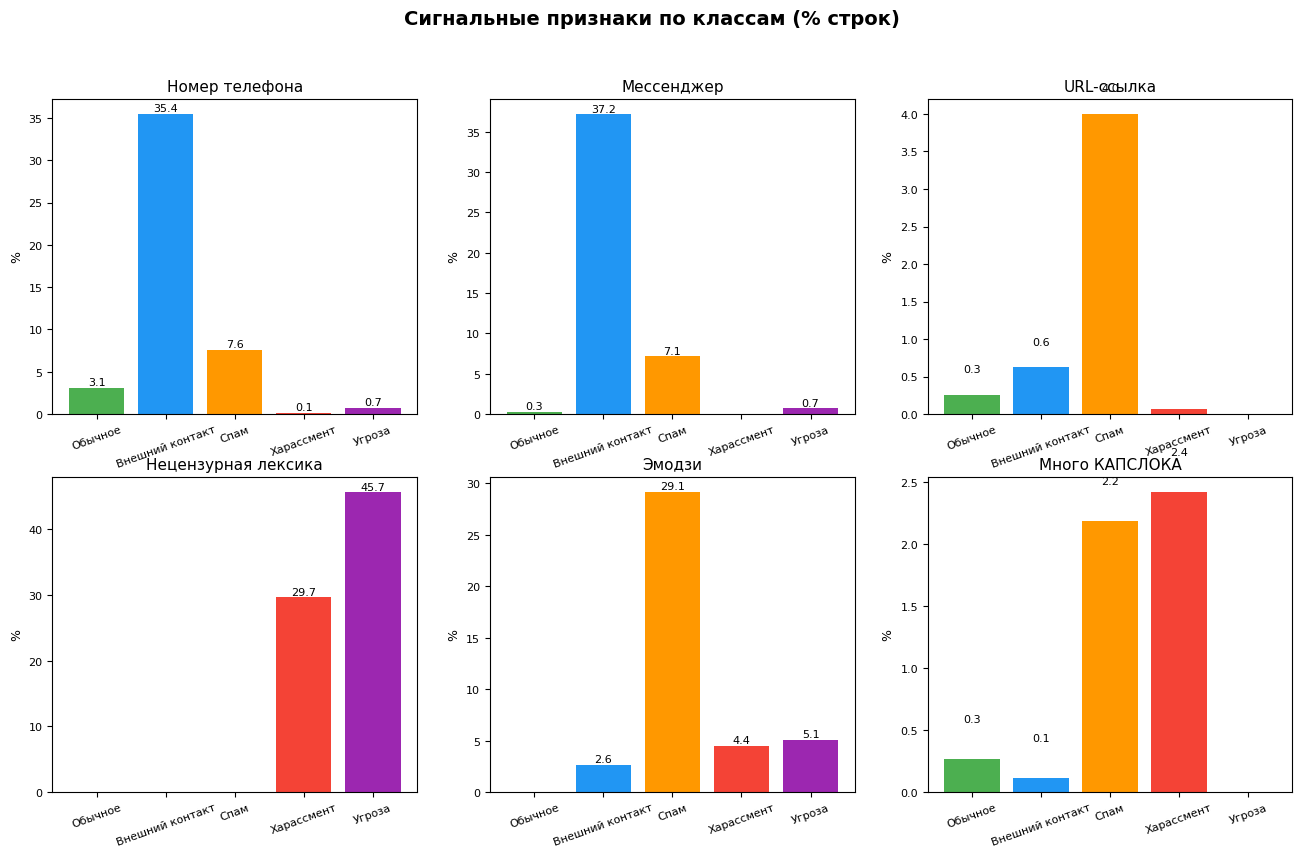

In [16]:
fig = plot_signal_features(full, save_path="eda_deep_signals.png")
plt.show()


---
<a id="section-words"></a>
## 6. Частотный анализ слов

Топ-слова по каждому классу — показывают доминирующую лексику и помогают понять,
что модель будет использовать как сигнал.


In [17]:
from collections import Counter

STOPWORDS = set(
    "и в на с не я по к за то что он а из это как его до он её они бы уже "
    "есть но у нет же ну так о да ты мне мой нас вас вы вот при всё будет "
    "можно тоже там здесь если для или со про этот эта эти был была были "
    "чем чего чему когда где куда откуда меня тебя себя мне тебе себе".split()
)

def top_words(texts, n=15):
    words = []
    for t in texts.dropna():
        for w in str(t).split():
            w2 = w.lower().strip(".,!?;:\'\"()[]{}👍😊📱✅🔴⚡")
            if len(w2) > 2 and w2 not in STOPWORDS:
                words.append(w2)
    return Counter(words).most_common(n)

print("=== ТОП-15 СЛОВ ПО КЛАССАМ ===\n")
for cls in CLASS_ORDER:
    texts = full[full["label"]==cls]["text"]
    top = top_words(texts, n=15)
    print(f"[{CLASS_RU[cls]}]  (n={len(texts):,})")
    for word, cnt in top:
        bar = "█" * min(30, cnt // max(1, max(c for _,c in top) // 30))
        print(f"  {word:<20} {bar} {cnt:,}")
    print()


=== ТОП-15 СЛОВ ПО КЛАССАМ ===



[Обычное]  (n=356,865)
  здравствуйте         ██████████████████████████████ 51,194
  добрый               ████████████████ 28,406
  день                 █████████████ 23,506
  вам                  ████████████ 20,950
  наличии              ████████ 13,861
  руб                  ███████ 13,378
  пожалуйста           ███████ 12,561
  завтра               ██████ 11,712
  сколько              ██████ 11,349
  только               ██████ 11,147
  все                  ██████ 10,917
  спасибо              ██████ 10,548
  сегодня              █████ 9,974
  могу                 █████ 9,776
  хорошо               █████ 8,929

[Внешний контакт]  (n=8,003)
  пожалуйста           ██████████████████████████████ 1,770
  номер                ██████████████████████████ 1,591
  вам                  ██████████████████████ 1,355
  напишите             ██████████████████████ 1,309
  через                ██████████████████ 1,118
  ватсап               ████████████████ 992
  номеру               ████████████

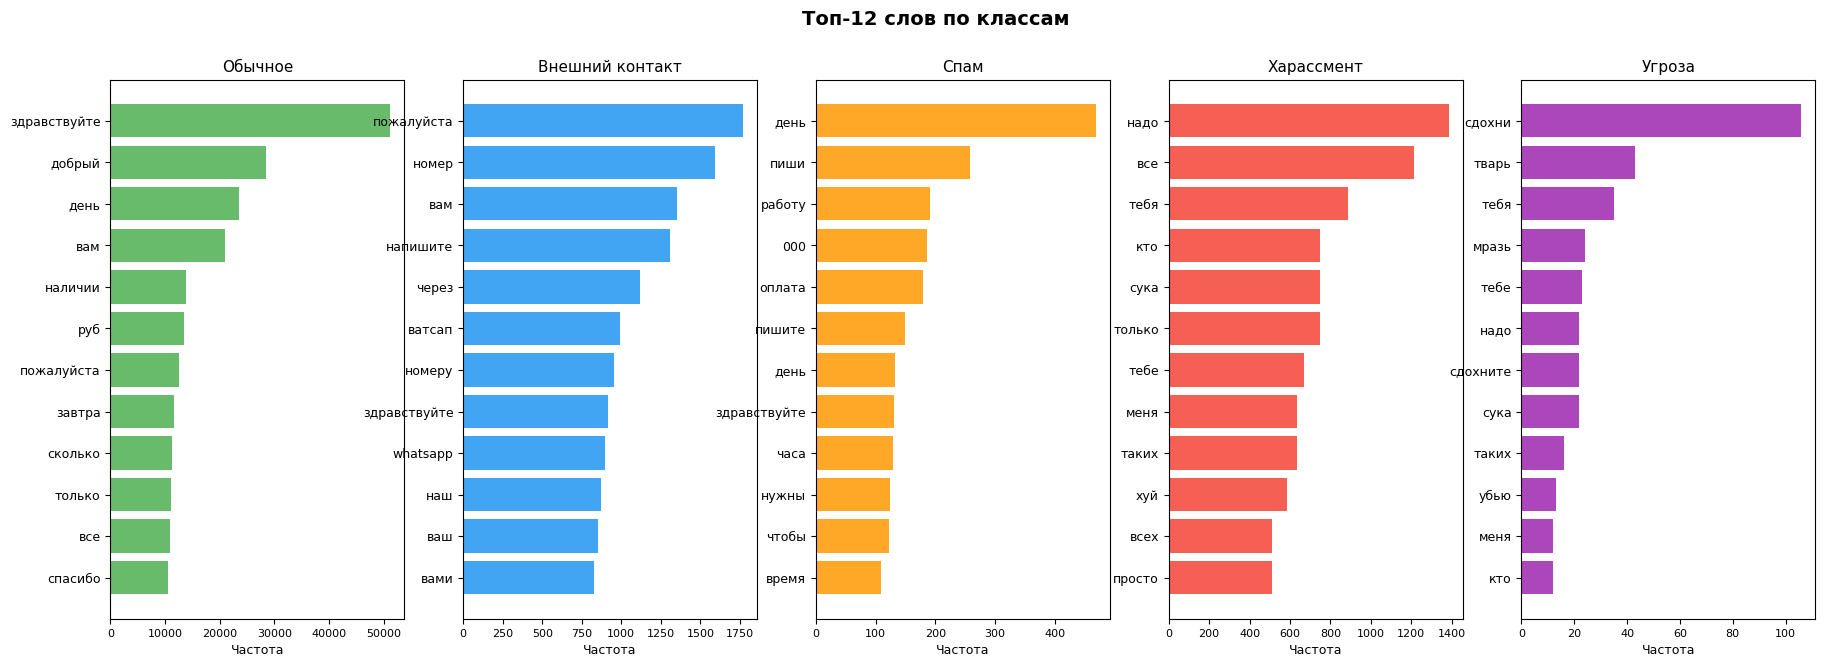

In [18]:
fig = plot_top_words(full, n=12, save_path="eda_deep_words.png")
plt.show()


In [19]:
# Топ-слова только для реальных Авито (не из внешних источников)
print("=== ТОП-10 СЛОВ: только Авито-оригинал (harassment, threat) ===")
for cls in ["harassment", "threat"]:
    texts = full[(full["label"]==cls) & (full["source"]=="real")]["text"]
    print(f"\n[{CLASS_RU[cls]}] (реальных Авито: {len(texts):,})")
    for w, cnt in top_words(texts, n=10):
        print(f"  {w}: {cnt}")


=== ТОП-10 СЛОВ: только Авито-оригинал (harassment, threat) ===

[Харассмент] (реальных Авито: 87)
  бля: 23
  хуй: 11
  пиздец: 11
  хули: 4
  хуйня: 4
  жопу: 4
  ебать: 4
  надо: 3
  вообще: 3
  ебаться: 3

[Угроза] (реальных Авито: 4)
  номеру: 2
  менеджер: 2
  здравствуйте: 1
  заинтересовала: 1
  данная: 1
  вакансия: 1
  наберите: 1
  напишите: 1
  вотсап: 1
  телеграм: 1


---
<a id="section-domain"></a>
## 7. Сравнение доменов: Авито vs Внешние источники

Ключевой вопрос: **насколько AlexSham (ok.ru) и paradetox похожи на Авито?**

Различия:
- **ok.ru** — публичные комментарии в соцсети; длинные политические дискуссии, споры
- **Авито** — частная переписка; короткие, деловые; контекст купли-продажи
- **paradetox** — Twitter/VK-комментарии; мемы, культурные отсылки

Это называется **domain shift** — риск, что модель выучит ok.ru-стиль оскорблений,
а не Авито-стиль.


In [20]:
print("=== СРАВНЕНИЕ ДЛИН: Авито (real) vs AlexSham vs paradetox ===")
for cls in ["harassment", "threat"]:
    print(f"\n[{CLASS_RU[cls]}]:")
    for src in ["real","alexsham","paradetox","synthetic"]:
        sub = full[(full["label"]==cls) & (full["source"]==src)]["text_len"]
        if len(sub) == 0: continue
        print(f"  {src:<12}: n={len(sub):>5,}  "
              f"median={sub.median():.0f}  "
              f"mean={sub.mean():.0f}  "
              f"max={sub.max():.0f}")


=== СРАВНЕНИЕ ДЛИН: Авито (real) vs AlexSham vs paradetox ===

[Харассмент]:
  real        : n=   87  median=25  mean=43  max=283
  alexsham    : n=14,915  median=51  mean=73  max=400
  paradetox   : n=6,060  median=58  mean=64  max=181
  synthetic   : n=  204  median=52  mean=75  max=546

[Угроза]:
  real        : n=    4  median=79  mean=84  max=167
  alexsham    : n=  195  median=48  mean=78  max=388
  synthetic   : n=   77  median=47  mean=58  max=260


In [21]:
print("=== ПРИМЕРЫ: harassment из РАЗНЫХ источников ===\n")
for src in ["real", "alexsham", "paradetox", "synthetic"]:
    subset = full[(full["label"]=="harassment") & (full["source"]==src)]["text"].dropna()
    print(f"--- {src} (n={len(subset):,}) ---")
    for t in subset.sample(min(4, len(subset)), random_state=33):
        print(f"  {str(t)[:115]}")
    print()


=== ПРИМЕРЫ: harassment из РАЗНЫХ источников ===

--- real (n=87) ---
  Денег сколько за жопу
  Может радику пиздец просто
  Ладно давай удачи тогда хули то да то нет я азартнее тебе сказал что коробку как найду от дам коробки пока что нету
  Да в принципе и так по хуй
Забивай за 30, бабки пиздец нужны

--- alexsham (n=14,915) ---
  пидарасы. эта едино блядливая россия. даже не желаю писать про них, с большой буквы. страна имеет 40 процентов поле
  белой руси воины нужны а не пидарасы будь достоин своих предков
  из подтишька по мышачи умеют пидоры бить.
  стрелять тварей надо

--- paradetox (n=6,060) ---
  хуй тебе на рыло, а не донбасс, губу закатай долбоеб!!!
  если бы не их музыка,я бы наверное покончил с собойибо проблемы были дохуя хуевые(
  Каким злобным уебаном надо быть,
  пидор ты гнойный сидиш за границей и мутиш народ козлина ваша демократия нам не к чему



--- synthetic (n=204) ---
  молодец автор. все расписал навалятам и прочим ублюдкам,что их ждет. готовьте чумадана,господа.
  бараны! хотите скакать одолжите скакалку у хохлов, напрыгаетесь, потом вякать про рейтинг будете!!!
  тогда все мужики еанутые. вертолетик хоть и маленький, тем не менее это чудо инженерной мысли, бабам этого не понят
  писатели хреновы если бы не путин вы бы давно америкосам задницу лизали



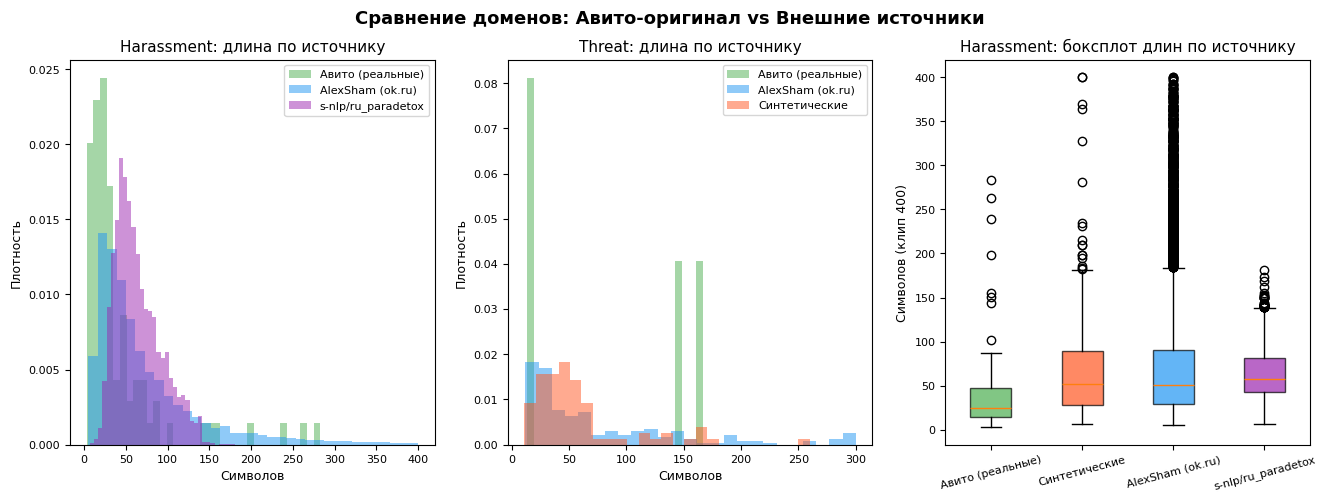

In [22]:
fig = plot_domain_comparison(full, save_path="eda_deep_domain.png")
plt.show()


---
<a id="section-risks"></a>
## 8. Риски и ограничения датасета


In [23]:
print("=== КОЭФФИЦИЕНТ ДИСБАЛАНСА ===")
vc = full["label"].value_counts()
max_cls = vc.max()
for cls in CLASS_ORDER:
    ratio = max_cls / vc.get(cls, 1)
    print(f"  normal / {CLASS_RU[cls]:<20} = {ratio:>8,.0f}x")

print()
print("=== ДОЛЯ 'НЕНАДЁЖНЫХ' СТРОК В КЛАССЕ ===")
print("(синтетика + внешние источники — не оригинальный Авито)")
for cls in CLASS_ORDER:
    total = (full["label"]==cls).sum()
    unreliable = ((full["label"]==cls) & (full["source"]!="real")).sum()
    pct = unreliable / total * 100 if total > 0 else 0
    risk = "" if pct > 80 else "" if pct > 40 else ""
    print(f"  {risk} {CLASS_RU[cls]:<22}: {pct:.1f}%  ({unreliable:,}/{total:,})")


=== КОЭФФИЦИЕНТ ДИСБАЛАНСА ===
  normal / Обычное              =        1x
  normal / Внешний контакт      =       45x
  normal / Спам                 =      170x
  normal / Харассмент           =       17x
  normal / Угроза               =    1,293x

=== ДОЛЯ 'НЕНАДЁЖНЫХ' СТРОК В КЛАССЕ ===
(синтетика + внешние источники — не оригинальный Авито)
  🟢 Обычное               : 0.0%  (0/356,865)
  🟠 Внешний контакт       : 45.9%  (3,676/8,003)
  🔴 Спам                  : 89.5%  (1,881/2,101)
  🔴 Харассмент            : 99.6%  (21,179/21,266)
  🔴 Угроза                : 98.6%  (272/276)


In [24]:
print("=== РАЗМЕР VAL/TEST ПО КЛАССАМ (только реальные Авито) ===")
print("Это сколько примеров у нас есть для ЧЕСТНОЙ оценки модели:")
for name, df_eval in [("Val", val), ("Test", test)]:
    print(f"\n{name}:")
    vc = df_eval["label"].value_counts().reindex(CLASS_ORDER).fillna(0)
    for cls in CLASS_ORDER:
        cnt = int(vc.get(cls, 0))
        risk = "" if cnt < 10 else ""
        print(f"  {risk} {CLASS_RU[cls]:<22}: {cnt:>5,}")


=== РАЗМЕР VAL/TEST ПО КЛАССАМ (только реальные Авито) ===
Это сколько примеров у нас есть для ЧЕСТНОЙ оценки модели:

Val:
  ✅ Обычное               : 35,686
  ✅ Внешний контакт       :   432
  ✅ Спам                  :    22
  ⚠️ Харассмент            :     8
  ⚠️ Угроза                :     1

Test:
  ✅ Обычное               : 35,686
  ✅ Внешний контакт       :   432
  ✅ Спам                  :    22
  ⚠️ Харассмент            :     8
  ⚠️ Угроза                :     1


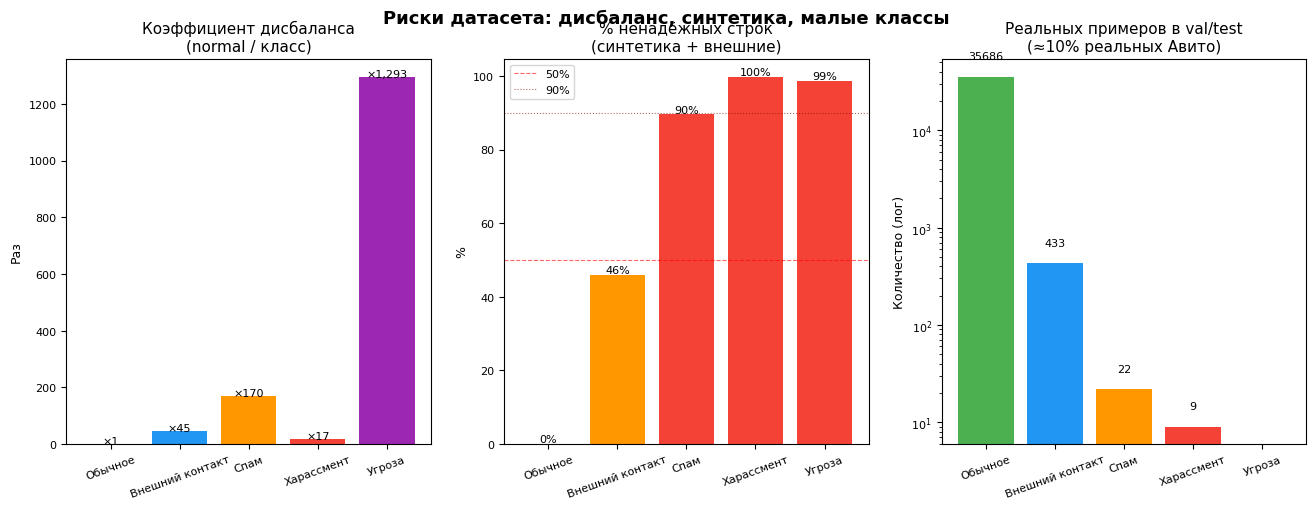

In [25]:
fig = plot_risks(full, save_path="eda_deep_risks.png")
plt.show()


---
<a id="section-conclusion"></a>
## 9. Вывод: что это значит для модели

### Итоговая таблица качества данных

| Класс | Авито-реальных | Всего в train | % ненадёжных | Риск |
|---|---|---|---|---|
| normal | 356 865 | 285 493 | 0% | Отлично |
| external | 4 327 | 7 139 | 51% | Умеренный |
| spam | 220 | 2 057 | 89% | Высокий |
| harassment | 87 | 21 250 | 99.6% | Высокий (доменный сдвиг) |
| threat | 4 | 274 | 98.5% | Критический |

### Рекомендации для обучения модели

1. **`class_weight='balanced'`** или кастомные веса — обязательно, дисбаланс 1:1300 для threat
2. **Threshold calibration** — после обучения настроить порог для каждого класса отдельно
3. **Метрика**: Precision@normal ≥ 0.95 (бизнес-требование), macro-F1 для минорных
4. **Домен**: harassment/threat обучен на ok.ru/Twitter данных → может плохо работать
   на специфически Авито-стиле. Нужна **active learning** итерация после деплоя.
5. **threat val/test**: только 1 пример в val → метрики для threat будут крайне нестабильны.
   Нужно ручная разметка ещё хотя бы 50–100 реальных Авито-угроз.
6. **spam**: 89% синтетика — стиль спама на Авито (рекрутинг, коммерция) отличается
   от SMS-спама. Риск ложных срабатываний на легитимные деловые сообщения.


In [26]:
# Финальная сводная таблица
summary = []
for cls in CLASS_ORDER:
    real_n   = full[(full["label"]==cls) & (full["source"]=="real")].shape[0]
    total_n  = (full["label"]==cls).sum()
    train_n  = (train["label"]==cls).sum()
    val_n    = (val["label"]==cls).sum()
    unreliable_pct = (1 - real_n / total_n) * 100 if total_n > 0 else 0
    summary.append({
        "Класс":              CLASS_RU[cls],
        "Авито-реальных":     real_n,
        "Всего в датасете":   total_n,
        "В train":            train_n,
        "В val":              val_n,
        "% ненадёжных":       f"{unreliable_pct:.0f}%",
        "Дисбаланс к normal": f"1:{full[full['label']=='normal'].shape[0] // max(total_n,1):,}",
    })

display(pd.DataFrame(summary).set_index("Класс"))
print()
print("Ноутбук завершён. Все графики сохранены в корне проекта.")


,Авито-реальных,Всего в датасете,В train,В val,% ненадёжных,Дисбаланс к normal
Класс,,,,,,
Обычное,356865,356865,285493,35686,0%,1:1
Внешний контакт,4327,8003,7139,432,46%,1:44
Спам,220,2101,2057,22,90%,1:169
Харассмент,87,21266,21250,8,100%,1:16
Угроза,4,276,274,1,99%,"1:1,292"



Ноутбук завершён. Все графики сохранены в корне проекта.
